<a href="https://colab.research.google.com/github/realRandomPL/ThucHanhDeepLearning/blob/main/ThucHanhDeepLearning_Tuan04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
from google.colab import drive

mnist_train = '/content/mnist_train_small.csv'
mnist_test = '/content/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


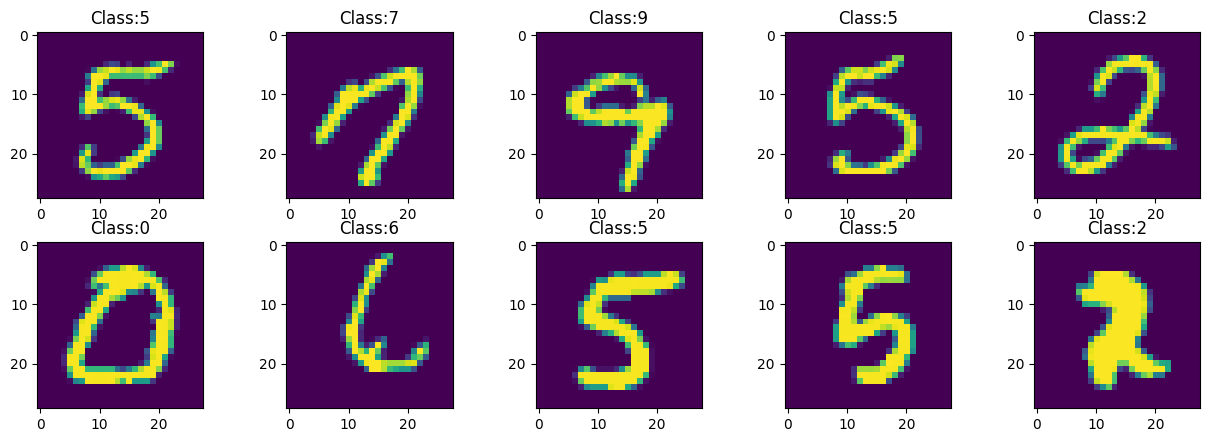

In [ ]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype('float32') /255
X_test = X_test.astype('float32') /255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1,verbose=1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8310 - loss: 0.6045 - val_accuracy: 0.9340 - val_loss: 0.2173
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9531 - loss: 0.1543 - val_accuracy: 0.9550 - val_loss: 0.1451
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9704 - loss: 0.1020 - val_accuracy: 0.9625 - val_loss: 0.1192
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9757 - loss: 0.0799 - val_accuracy: 0.9755 - val_loss: 0.0956
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9808 - loss: 0.0618 - val_accuracy: 0.9725 - val_loss: 0.0938
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.9838 - loss: 0.0537 - val_accuracy: 0.9775 - val_loss: 0.0757
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.9852 - loss: 0.0473 - val_accuracy: 0.9760 - val_loss: 0.0781
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9876 - loss: 0.

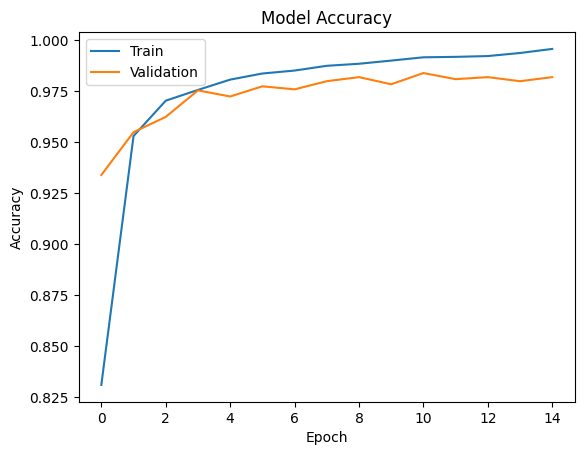

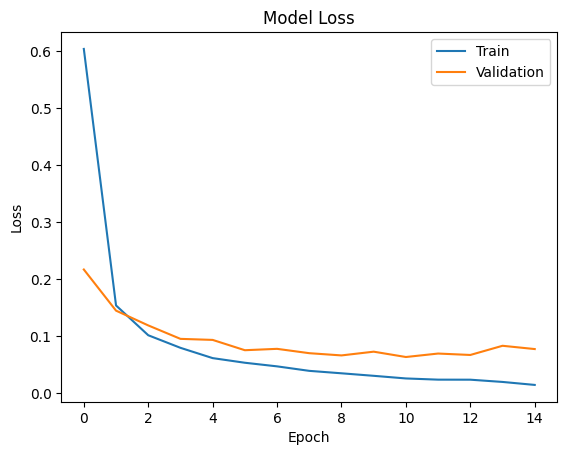

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.0550263449549675
Test accuracy: 0.9840984344482422


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[3.55632574e-06 3.22095980e-06 9.99993205e-01 1.89664895e-10
  4.99272259e-19 3.97191740e-14 1.19077805e-08 4.64489955e-18
  1.08951592e-09 1.20317156e-21]]
2 2


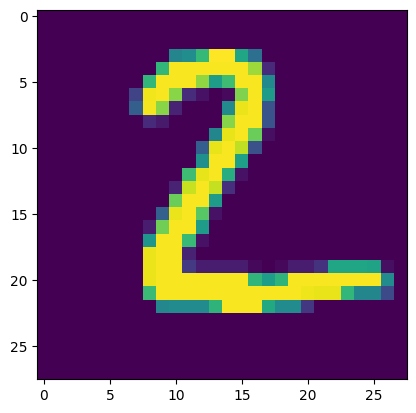

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
[[1.8816003e-07 9.9976391e-01 2.2234066e-05 5.3672090e-07 1.9564273e-04
  2.2761483e-07 1.3970771e-06 6.0870761e-06 9.7158454e-06 2.7942859e-08]]
1 1


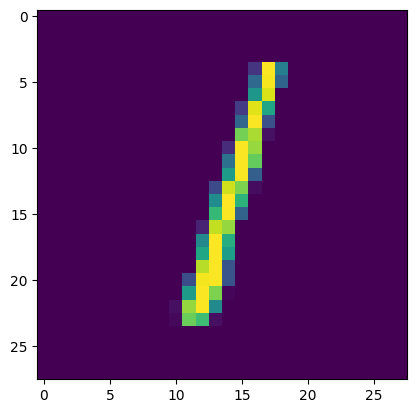

In [ ]:
model = Sequential()
model.add(Input(shape = input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()


In [7]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, BatchNormalization, Dropout
from keras.models import Sequential
from keras import Input
from tensorflow.keras.datasets import cifar10

# 1. Nạp nhanh dữ liệu CIFAR10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

num_classes = 10
input_shape = (32, 32, 3)

# 2. Ép kiểu và chuẩn hóa trực tiếp (Bỏ Dataset Pipeline phức tạp)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

y_train_encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)

# 3. Kiến trúc mạng CNN gọn nhẹ, có Dropout chống Overfitting nhưng tính toán rất nhanh
model1 = Sequential()
model1.add(Input(shape=input_shape))

# Tầng chập 1
model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')) # Increased filters
model1.add(BatchNormalization()) # Added BatchNormalization
model1.add(MaxPool2D(pool_size=(2, 2)))
model1.add(Dropout(0.2))

# Tầng chập 2
model1.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same')) # Increased filters
model1.add(BatchNormalization()) # Added BatchNormalization
model1.add(MaxPool2D(pool_size=(2, 2)))
model1.add(Dropout(0.2))

# Tầng Phân loại
model1.add(Flatten())
model1.add(Dense(units=256, activation='relu')) # Increased units
model1.add(BatchNormalization()) # Added BatchNormalization
model1.add(Dropout(0.3))
model1.add(Dense(units=num_classes, activation='softmax'))

# 4. Biên dịch mô hình
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Huấn luyện với Batch Size lớn (256) để ép GPU chạy hết công suất
# Khi có GPU T4, mỗi Epoch chỉ mất khoảng 3 - 5 giây! Tổng 15 Epochs chưa tới 1 phút.
history1 = model1.fit(X_train, y_train_encoded, batch_size=256, epochs=15, validation_split=0.1, verbose=1)

# 6. Đánh giá kết quả trên tập kiểm thử
score1 = model1.evaluate(X_test, y_test_encoded, verbose=2)
print('Test loss:', score1[0])
print('Test accuracy:', score1[1])

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.5012 - loss: 1.4787 - val_accuracy: 0.0952 - val_loss: 7.9314
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.6438 - loss: 1.0221 - val_accuracy: 0.1376 - val_loss: 16.6741
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.7003 - loss: 0.8536 - val_accuracy: 0.2582 - val_loss: 7.9568
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.7386 - loss: 0.7422 - val_accuracy: 0.6532 - val_loss: 1.0348
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7703 - loss: 0.6519 - val_accuracy: 0.6894 - val_loss: 0.9265
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7969 - loss: 0.5804 - val_accuracy: 0.7142 - val_loss: 0.9195
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8230 - loss: 0.5029 - val_accuracy: 0.6330 - val_loss: 1.1620
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.8453 - loss: 0.4445 - val_acc

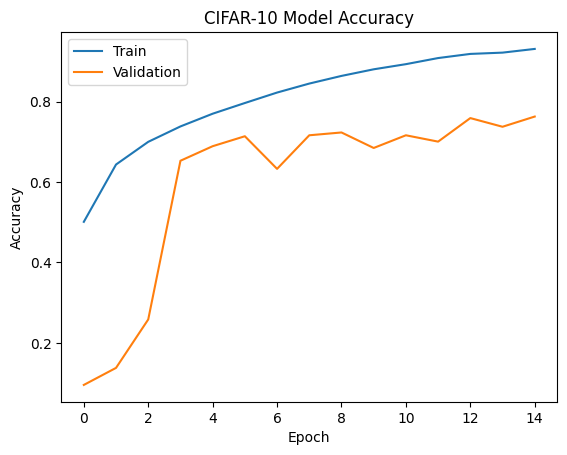

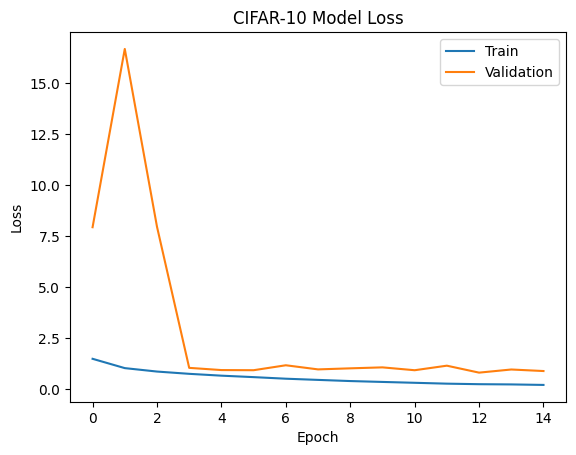

In [8]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('CIFAR-10 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('CIFAR-10 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()